In [1]:
from collections import defaultdict

import pymovements as pm
import polars as pl

C:\Users\saphi\PycharmProjects\S5\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
pm.DatasetLibrary.names()

['BSC',
 'BSCII',
 'ChineseReading',
 'CoLAGaze',
 'CodeComprehension',
 'CopCo',
 'DAEMONS',
 'DIDEC',
 'EMTeC',
 'ETDD70',
 'FakeNewsPerception',
 'Gaze4Hate',
 'GazeBase',
 'GazeBaseVR',
 'GazeGraph',
 'GazeOnFaces',
 'HBN',
 'IITB_HGC',
 'InteRead',
 'JuDo1000',
 'MECOL1W1',
 'MECOL2W1',
 'MECOL2W2',
 'MouseCursor',
 'OneStop',
 'PoTeC',
 'PotsdamBingeRemotePVT',
 'PotsdamBingeWearablePVT',
 'Provo',
 'RaCCooNS',
 'SBSAT',
 'TECO',
 'ToyDataset',
 'ToyDatasetEyeLink',
 'UCL']

In [4]:
dataset_paths = pm.DatasetPaths(root='data/')
dataset = pm.Dataset('PoTeC', path=dataset_paths)

dataset.path

WindowsPath('data/PoTeC')

In [5]:
dataset.download()

INFO:pymovements.dataset.dataset:
        You are downloading the Potsdam Textbook Corpus. Please be aware that pymovements does not
        host or distribute any dataset resources and only provides a convenient interface to
        download the public dataset resources that were published by their respective authors.

        Please cite the referenced publication if you intend to use the dataset in your research.
        


PoTeC.zip: 100%|██████████| 703M/703M [01:30<00:00, 8.16MB/s] 


Checking integrity of PoTeC.zip


fixation.zip: 100%|██████████| 7.16M/7.16M [00:00<00:00, 22.6MB/s]


Checking integrity of fixation.zip


...

Extracting archive: 100%|██████████| 1812/1812 [00:24<00:00, 75.47file/s]


Extracting fixation.zip to data\PoTeC\precomputed_events


Extracting archive: 100%|██████████| 1812/1812 [00:02<00:00, 697.83file/s]


Extracting reading_measures.zip to data\PoTeC\precomputed_reading_measures


Extracting archive: 100%|██████████| 1802/1802 [00:03<00:00, 516.04file/s]


In [6]:
dataset.extract(remove_finished=True)

Extracting PoTeC.zip to data\PoTeC\raw


Extracting archive: 100%|██████████| 1812/1812 [00:21<00:00, 85.44file/s] 


Extracting fixation.zip to data\PoTeC\precomputed_events


Extracting archive: 100%|██████████| 1812/1812 [00:02<00:00, 834.42file/s]


Extracting reading_measures.zip to data\PoTeC\precomputed_reading_measures


Extracting archive: 100%|██████████| 1802/1802 [00:02<00:00, 630.22file/s]


In [8]:
dataset.scan()

subject_id,text_id,filepath
i64,str,str
0,"""b0""","""raw_data\reader0_b0_raw_data.t…"
0,"""b1""","""raw_data\reader0_b1_raw_data.t…"
0,"""b2""","""raw_data\reader0_b2_raw_data.t…"
0,"""b3""","""raw_data\reader0_b3_raw_data.t…"
0,"""b4""","""raw_data\reader0_b4_raw_data.t…"
…,…,…
9,"""b2""","""raw_data\reader9_b2_raw_data.t…"
9,"""b3""","""raw_data\reader9_b3_raw_data.t…"
9,"""p0""","""raw_data\reader9_p0_raw_data.t…"


In [34]:
sentences = pl.read_csv("C:\\Users\\saphi\\PycharmProjects\\S5\\wg1-image-creation\\data\\stimuli_MultiplEYE_TOY_X_x_1_1\\uncorrected_constituency_trees.tsv", encoding='utf-8')

ComputeError: found more fields than defined in 'Schema'

Consider setting 'truncate_ragged_lines=True'.

In [35]:
sentences.head()

index,sent_index_in_text,sentence,spacy_constituency_tree,str_constituents,spacy_pos_tags,constituents,text_id_numeric,text_id
i64,i64,str,str,str,str,str,i64,str
0,1,"""Ein Zyklotron besteht aus eine…","""(S (NP (ART Ein) (NN Zyklotron…","""['(S (NP (ART Ein) (NN Zyklotr…","""['DET', 'NOUN', 'VERB', 'ADP',…","""[Ein Zyklotron besteht aus ein…",6,"""p0"""
1,2,"""Die Kammer ist in zwei D-förmi…","""(S (NP (ART Die) (NN Kammer)) …","""['(S (NP (ART Die) (NN Kammer)…","""['DET', 'NOUN', 'AUX', 'ADP', …","""[Die Kammer ist in zwei D-förm…",6,"""p0"""
2,3,"""Die von der Ionenquelle im Spa…","""(S (NP (ART Die) (AP (APPR von…","""['(S (NP (ART Die) (AP (APPR v…","""['DET', 'ADP', 'DET', 'NOUN', …","""[Die von der Ionenquelle im Sp…",6,"""p0"""
3,4,"""Da im Inneren der Kammerhälfte…","""(S (KOUS Da) (PP (APPRART im) …","""['(S (KOUS Da) (PP (APPRART im…","""['SCONJ', 'ADP', 'NOUN', 'DET'…","""[Da im Inneren der Kammerhälft…",6,"""p0"""
4,5,"""Wird die Hochfrequenz nun gena…","""(S (VAFIN Wird) (NP (ART die) …","""['(S (VAFIN Wird) (NP (ART die…","""['AUX', 'DET', 'NOUN', 'ADV', …","""[Wird die Hochfrequenz nun gen…",6,"""p0"""


In [41]:
df = sentences.select(pl.col("sentence"), pl.col("sent_index_in_text"), pl.col("text_id_numeric"))

In [52]:
result = (
    df
    .sort(["text_id_numeric", "sent_index_in_text"])  # ensure correct sentence order
    .group_by("text_id_numeric")
    .agg(
        pl.col("sentence").str.join(" ").alias("full_text")
    )
)

result


text_id_numeric,full_text
i64,str
0,"""Um das Vorhandensein der Polym…"
1,"""In der homologen Rekombination…"
2,"""Wurzeln entziehen dem Boden Wa…"
3,"""Motormoleküle sind Enzyme, wel…"
4,"""Eine chlorophyllhaltige Parenc…"
…,…
7,"""Wenn ein ruhendes Atom ein Pho…"
8,"""Photonische Kristalle sind räu…"
9,"""Der entscheidende Durchbruch z…"


In [63]:
import pathlib
path = pathlib.Path("wg1-image-creation/data/stimuli_MultiplEYE_TOY_X_x_1_1/data/processed").mkdir(parents=True, exist_ok=True)
result.write_csv(pathlib.Path("wg1-image-creation/data/stimuli_MultiplEYE_TOY_X_x_1_1/data/results.csv"))

In [51]:
result

text_id_numeric,full_text
i64,str
0,"""Um das Vorhandensein der Polym…"
1,"""In der homologen Rekombination…"
2,"""Wurzeln entziehen dem Boden Wa…"
3,"""Motormoleküle sind Enzyme, wel…"
4,"""Eine chlorophyllhaltige Parenc…"
…,…
7,"""Wenn ein ruhendes Atom ein Pho…"
8,"""Photonische Kristalle sind räu…"
9,"""Der entscheidende Durchbruch z…"


In [9]:
dataset.load()

Loading gaze files: 100%|██████████| 905/905 [00:31<00:00, 28.80file/s]


In [11]:
# we will work with gaze data from the first recording

gaze = dataset.gaze[0]

# extract horizontal and vertical coordinates from the position column
df = gaze.samples

df = df.with_columns([
    pl.col("pixel").list.get(0).alias("pos_x"),
    pl.col("pixel").list.get(1).alias("pos_y"),
])

# Assign back
gaze.samples = df

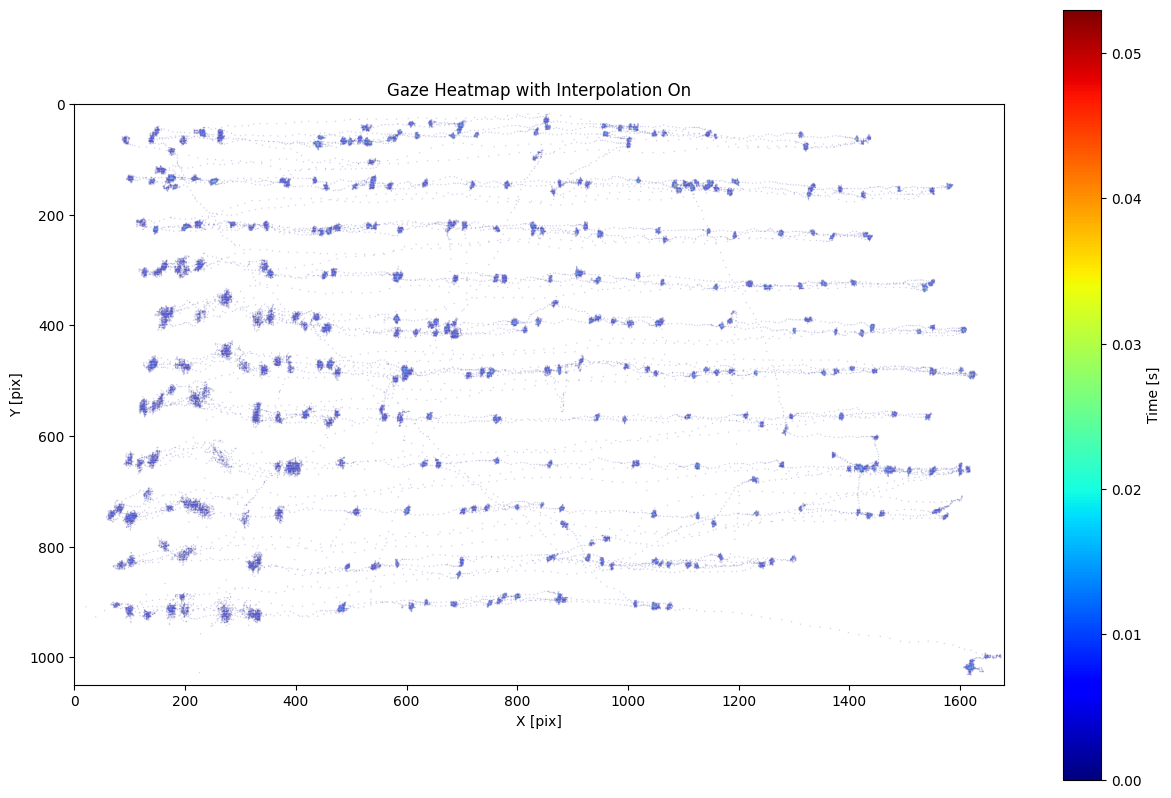

In [18]:
fig, ax = pm.plotting.heatmap(
    gaze=gaze,
    position_column='pixel',
    origin='upper',
    show_cbar=True,
    cbar_label='Time [s]',
    title='Gaze Heatmap with Interpolation On',
    xlabel='X [pix]',
    ylabel='Y [pix]',
    gridsize=[dataset.definition.experiment.screen.height_px, dataset.definition.experiment.screen.width_px],
    #interpolation= 'none',
)

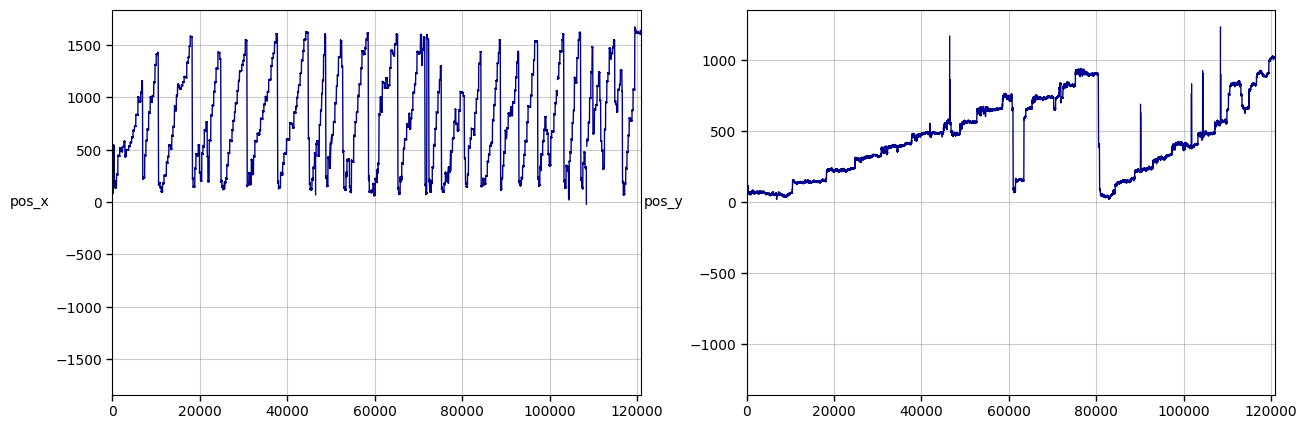

(<Figure size 1500x500 with 2 Axes>, <Axes: ylabel='pos_x'>)

In [13]:
pm.plotting.tsplot(
    gaze,
    channels=['pos_x', 'pos_y'],
    # Set separate y-axis for each channel.
    share_y=False,
    line_color="darkblue")

In [17]:
dataset.definition

DatasetDefinition(name='PoTeC', long_name='Potsdam Textbook Corpus', mirrors={}, resources=[ResourceDefinition(content='gaze', filename='PoTeC.zip', url='https://osf.io/download/tgd9q/', mirrors=None, md5='cffd45039757c3777e2fd130e5d8a2ad', filename_pattern='reader{subject_id:d}_{text_id}_raw_data.tsv', filename_pattern_schema_overrides={'subject_id': <class 'int'>, 'text_id': <class 'str'>}, load_function=None, load_kwargs={'time_column': 'time', 'time_unit': 'ms', 'pixel_columns': ['x', 'y'], 'read_csv_kwargs': {'schema_overrides': {'time': Int64, 'x': Float32, 'y': Float32, 'pupil_diameter': Float32}, 'separator': '\t'}}), ResourceDefinition(content='precomputed_events', filename='fixation.zip', url='https://osf.io/download/d8pyg/', mirrors=None, md5='ecd9a998d07158922bb9b8cdd52f5688', filename_pattern='reader{subject_id:d}_{text_id}_uncorrected_fixations.tsv', filename_pattern_schema_overrides={'subject_id': <class 'int'>, 'text_id': <class 'str'>}, load_function=None, load_kwargs={'read_csv_kwargs': {'separator': '\t', 'null_values': '.'}}), ResourceDefinition(content='precomputed_reading_measures', filename='reading_measures.zip', url='https://osf.io/download/3ywhz/', mirrors=None, md5='efafec5ce074d8f492cc2409b6c4d9eb', filename_pattern='reader{subject_id:d}_{text_id}_merged.tsv', filename_pattern_schema_overrides={'subject_id': <class 'int'>, 'text_id': <class 'str'>}, load_function=None, load_kwargs={'read_csv_kwargs': {'separator': '\t', 'null_values': '.', 'infer_schema_length': 10000}})], experiment=<pymovements.gaze.experiment.Experiment object at 0x000001E6F6BAF5D0>, extract=None, custom_read_kwargs=None, column_map=None, trial_columns=None, time_column=None, time_unit=None, pixel_columns=None, position_columns=None, velocity_columns=None, acceleration_columns=None, distance_column=None)